# Postprocessing after Optimization

Import custom functions and define paths to datadirectories.

In [40]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
import numpy as np
import sys
import glob
import os
from pathlib import Path
scripts_dir = Path.cwd().parents[1]
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))
from gan_pipeline.core import custom_plots as custom_plots
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
import matplotlib.colors as mcolors
from postprocessing import PostProcessing
from well_evaluation import WellMismatch
from matplotlib.colors import ListedColormap
custom_plots.apply_custom_plotting_flavor()

# 1. Well data & testing dataset paths
well_data_path = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\datasets\well_data\Well_data.xlsx")
flumy_data_dir = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\datasets\testing\setting_2_nexus_1000_samples_ntg_67_chdepth_6_isbx_100\samples\facies\*.npy")

# 2. Optimized latent vector & realizations path
gan_data_dir_01 = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\outputs\post_optimization\Run_1_1_model_5_adjusted_loss_3000_steps_threshold_1\realizations\*.npy")
gan_data_dir_02 = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\outputs\post_optimization\Run_1_2_model_5_adjusted_loss_3000_steps_threshold_2\realizations\*.npy")
gan_data_dir_03 = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\outputs\post_optimization\Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5\realizations\*.npy")

# 3. Output direcories
output_dir_01 = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_1_model_5_adjusted_loss_3000_steps_threshold_1")
output_dir_02 = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_2_model_5_adjusted_loss_3000_steps_threshold_2")
output_dir_03 = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5")

In [13]:
def plot_dir_history(data_dir, ax=None, title_suffix=""):
    """Loads the first CSV file from a directory and plots its loss curves.

    Parameters:
    - data_dir: Path object or string of the directory containing the CSV.
    - ax: Matplotlib axis object (optional). Used for creating subplots.
    - title_suffix: Extra string to add to the plot title (optional).
    """
    path = Path(data_dir)

    try:
        # Find CSV files in this specific directory
        history_files = list(path.glob("*.csv"))
        if not history_files:
            print(f"Warning: No CSV files found in {path}")
            return

        # Load the first history file
        Loss = pd.read_csv(history_files[0])
        step = np.arange(len(Loss))

        # If no specific axis is provided, use the current active plot
        if ax is None:
            ax = plt.gca()

        # Plot setup
        ax.grid(True)
        for col in Loss.columns:
            # Fixed bug: added label=col so plt.legend() actually works
            ax.plot(step, Loss[col], label=col)

        ax.set_title(f"Loss Curves {title_suffix}".strip())
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Loss")

        # Calculate and print metrics
        mean_min_loss = Loss.min().mean()
        print(
            f"[{path.name}] Mean of minimum losses across columns: {mean_min_loss:.4f}"
        )

    except Exception as e:
        print(f"Error accessing history directory: {path}")
        print(e)

def compute_pixelwise_entropy(file_paths):
    """Computes pixel-wise Shannon entropy and mean normalized entropy

    for a list of categorical numpy file paths.
    """
    if not file_paths:
        return None, 0.0

    # Load and stack all realizations: shape (N, Height, Width)
    arrays = [np.load(fp) for fp in file_paths]
    stacked = np.stack(arrays, axis=0)

    # Identify unique classes across the dataset (e.g., 0, 1, 2)
    unique_classes = np.unique(stacked)
    num_classes = len(unique_classes)

    # If the entire subset contains only 1 class or 1 realization, entropy is 0
    if num_classes <= 1 or len(file_paths) <= 1:
        return np.zeros(stacked.shape[1:]), 0.0

    # Initialize entropy array matching the spatial dimensions
    entropy_map = np.zeros(stacked.shape[1:])

    # Calculate entropy per pixel
    for c in unique_classes:
        # Proportion of realizations where this pixel equals class 'c'
        p_c = np.mean(stacked == c, axis=0)

        # Use masked log to safely handle p_c == 0
        log_p_c = np.zeros_like(p_c)
        mask = p_c > 0
        log_p_c[mask] = np.log2(p_c[mask])

        entropy_map -= p_c * log_p_c

    # Normalize by max possible entropy: log2(num_classes)
    norm_entropy_map = entropy_map / np.log2(num_classes)
    mean_norm_entropy = np.mean(norm_entropy_map)

    return norm_entropy_map, mean_norm_entropy

[Run_1_1_model_5_adjusted_loss_3000_steps_threshold_1] Mean of minimum losses across columns: 4767.6407
[Run_1_2_model_5_adjusted_loss_3000_steps_threshold_2] Mean of minimum losses across columns: 15598.2542
[Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5] Mean of minimum losses across columns: 92142.1600


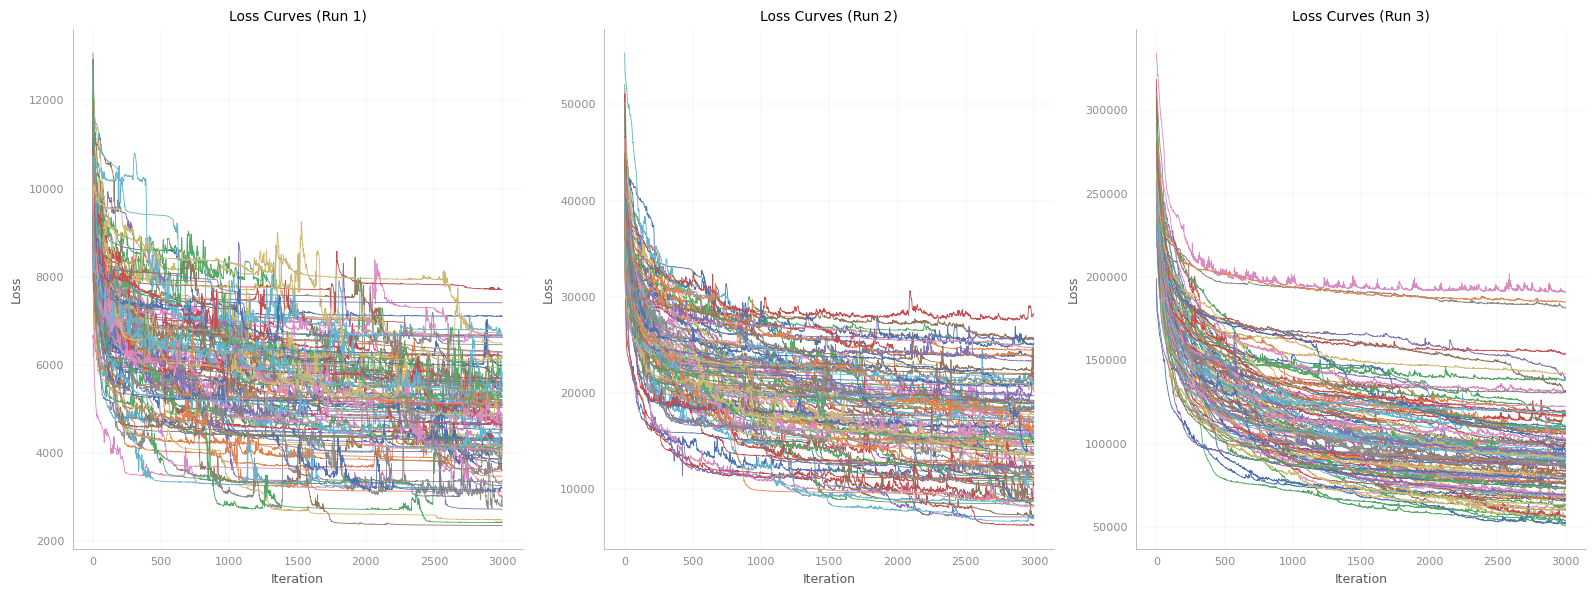

In [46]:
# Plotting the loss curves for both GAN runs
# 1. Define your separate directories
dir_1 = gan_data_dir_01.parent.parent
dir_2 = gan_data_dir_02.parent.parent
dir_3 = gan_data_dir_03.parent.parent



# 2. Create a figure with 1 row and 2 columns (Double Plots)
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# 3. Call your function for each directory, passing the respective axis
plot_dir_history(dir_1, ax=axes[0], title_suffix="(Run 1)")
plot_dir_history(dir_2, ax=axes[1], title_suffix="(Run 2)")
plot_dir_history(dir_3,ax=axes[2], title_suffix="(Run 3)")

# 4. Clean up layout and display
plt.tight_layout()
plt.savefig(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\loss_curve.png",dpi=400)
plt.show()

## Initialize postprocessing class

In [42]:
run_configs = [
    # Format: (gan_name, gan_description, out_dir, flumy_path, gan_path)
    (
        "Run 1", 
        "Run 1: Threshold of 1", 
        output_dir_01, 
        flumy_data_dir, 
        gan_data_dir_01
    ),
    (
        "Run 2", 
        "Run 2: Threshold of 2", 
        output_dir_02, 
        flumy_data_dir, 
        gan_data_dir_02
    ),
    (
        "Run 3", 
        "Run 3: Threshold of 5", 
        output_dir_03, 
        flumy_data_dir, 
        gan_data_dir_03
    )
]

validators = []

# Loop through the configurations
for gan_name, gan_description, out_dir, flumy_path, gan_path in run_configs:
    
    # 1. Create directories if they don't exist
    os.makedirs(out_dir, exist_ok=True)
    
    # 2. Initialize the validator
    validator = PostProcessing(
        flumy_name="setting 2",
        gan_name=gan_name,
        gan_description=gan_description,
        output_dir=out_dir,
        data_path=flumy_path,   # Dynamically assigns data_dir_1 or data_dir_2
        gan_path=gan_path       # Dynamically assigns gan_data_dir_1 or gan_data_dir_2
    )
    
    # 3. Load the samples
    validator.load_flumy_samples(limit=100)
    validator.load_gan_samples(limit=100)
    validators.append(validator)

Loading setting 2 samples (limit: 100)...
Loaded 100 setting 2 samples into memory.
Loading Run 1 samples (limit: 100)...
Loaded 100 Run 1 samples into memory.
Loading setting 2 samples (limit: 100)...
Loaded 100 setting 2 samples into memory.
Loading Run 2 samples (limit: 100)...
Loaded 100 Run 2 samples into memory.
Loading setting 2 samples (limit: 100)...
Loaded 100 setting 2 samples into memory.
Loading Run 3 samples (limit: 100)...
Loaded 100 Run 3 samples into memory.


Processing Run 1...
Saved combined 2D grid matrix to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_1_model_5_adjusted_loss_3000_steps_threshold_1\combined_grid_gan_X_3samples.png


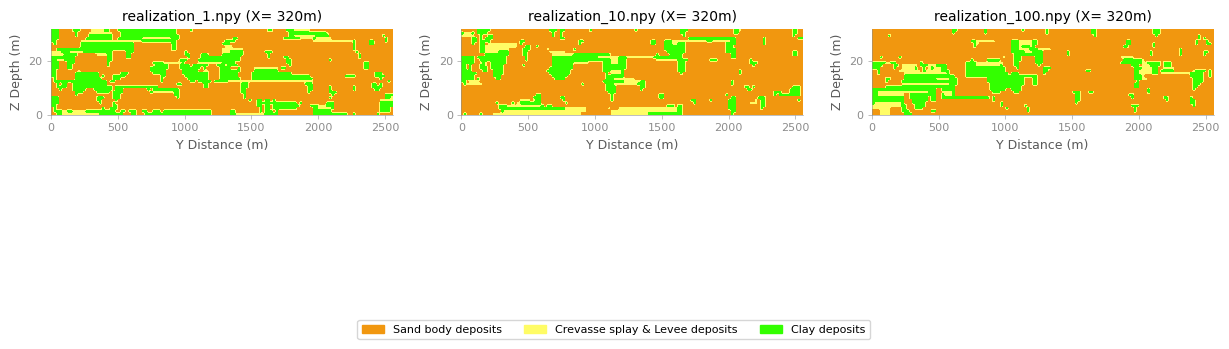


--- Generating 3D PyVista Entropy Map (Run 1) ---
[Run 1] Calculated Mean Voxel-Wise Entropy: 0.6855


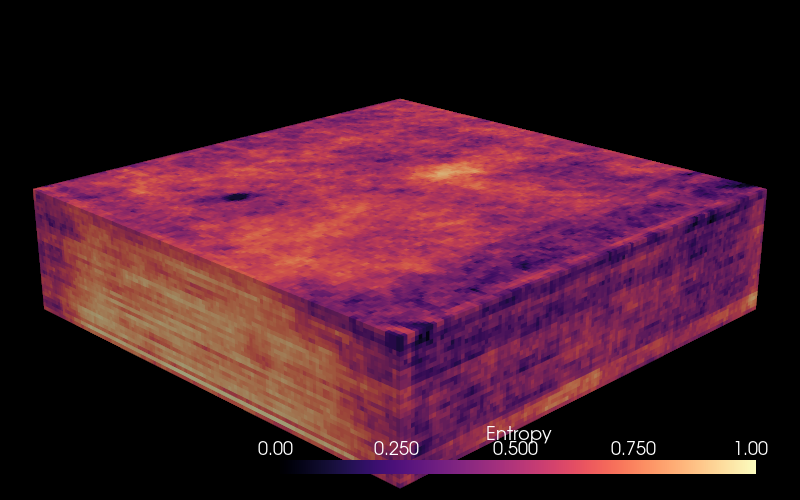

Processing Run 2...
Saved combined 2D grid matrix to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_2_model_5_adjusted_loss_3000_steps_threshold_2\combined_grid_gan_X_3samples.png


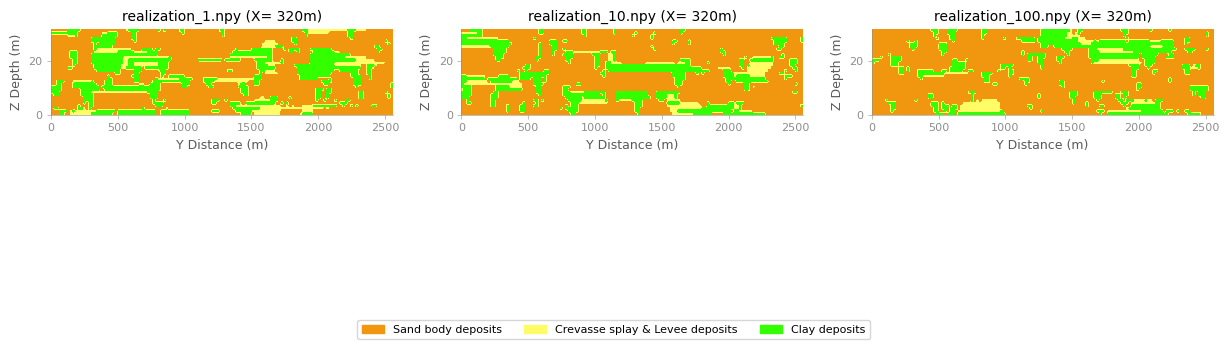


--- Generating 3D PyVista Entropy Map (Run 2) ---
[Run 2] Calculated Mean Voxel-Wise Entropy: 0.6852


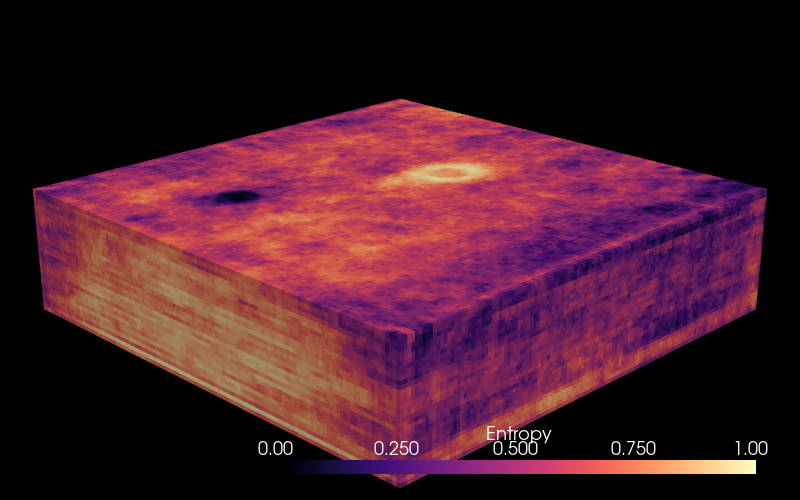

Processing Run 3...
Saved combined 2D grid matrix to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5\combined_grid_gan_X_3samples.png


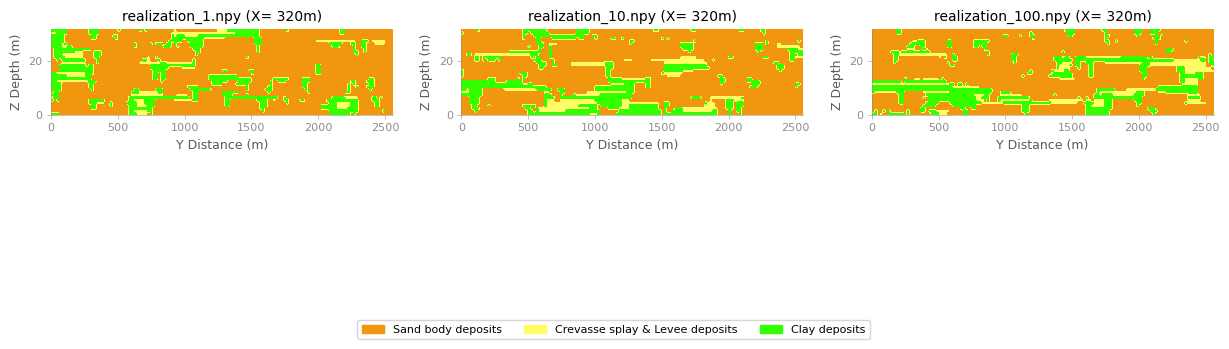


--- Generating 3D PyVista Entropy Map (Run 3) ---
[Run 3] Calculated Mean Voxel-Wise Entropy: 0.6631


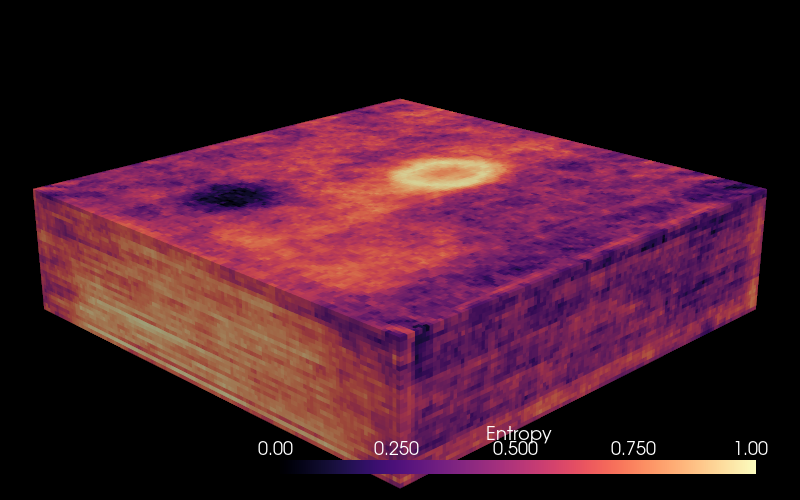

In [16]:
for i, validator in enumerate(validators):
    print(f"Processing {validator.gan_name}...")
    validator.plot_2d_slices(axis="X", num_samples=3, slice_indices=[16], save_plot=True)
    validator.plot_3d_entropy_pyvista()

## **Compute Macro-F1 scores**


Processing Well Mismatch for Run 1...
Loaded 64 well conditioning points.

--- Well Data Mismatch ---
Evaluated 100 realizations.
Average Macro F1 Score: 0.6965
Average F1 Class 1 (Channel): 0.7683
Average F1 Class 2 (Levee): 0.5602
Average F1 Class 3 (Overbank): 0.7610
-> Generating trajectory cross-section for Well: DEL-GT-01...
Saved well trajectory slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5\trajectory_slices\Run 1\well_trajectory_DEL-GT-01_1samples.png


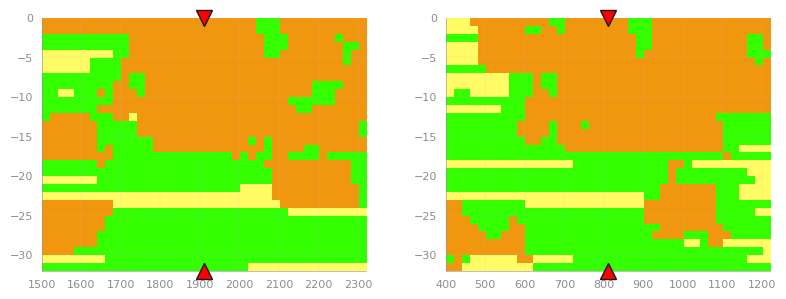


--- Generating Normalized Entropy Slices for Well: DEL-GT-01 (Run 1) ---
Saved well entropy slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5\trajectory_slices\Run 1\well_entropy_DEL-GT-01_Run_1.png


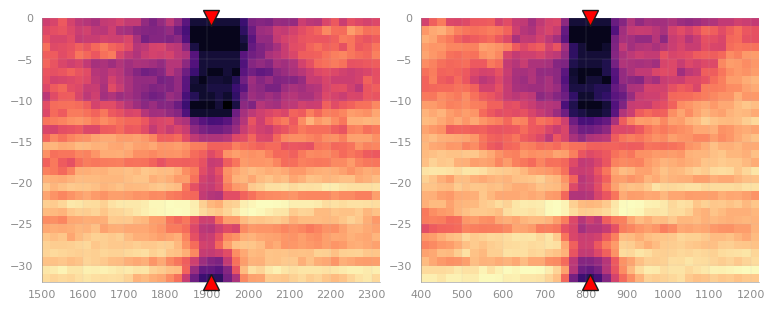

-> Generating trajectory cross-section for Well: DEL-GT-02-S2...
Saved well trajectory slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5\trajectory_slices\Run 1\well_trajectory_DEL-GT-02-S2_1samples.png


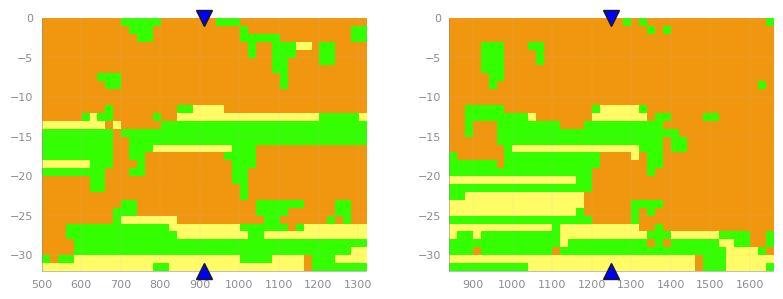


--- Generating Normalized Entropy Slices for Well: DEL-GT-02-S2 (Run 1) ---
Saved well entropy slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5\trajectory_slices\Run 1\well_entropy_DEL-GT-02-S2_Run_1.png


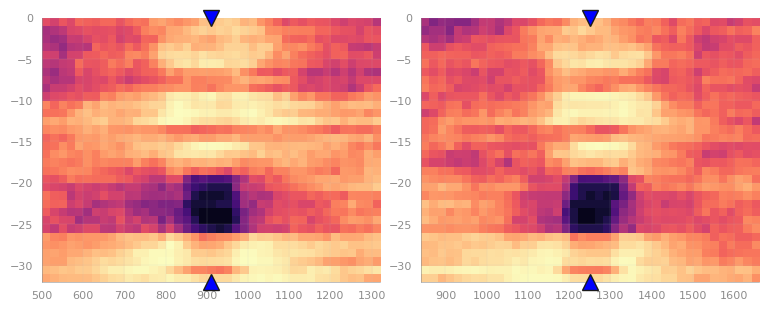


Processing Well Mismatch for Run 2...
Loaded 64 well conditioning points.

--- Well Data Mismatch ---
Evaluated 100 realizations.
Average Macro F1 Score: 0.7788
Average F1 Class 1 (Channel): 0.8384
Average F1 Class 2 (Levee): 0.6889
Average F1 Class 3 (Overbank): 0.8092
-> Generating trajectory cross-section for Well: DEL-GT-01...
Saved well trajectory slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5\trajectory_slices\Run 2\well_trajectory_DEL-GT-01_1samples.png


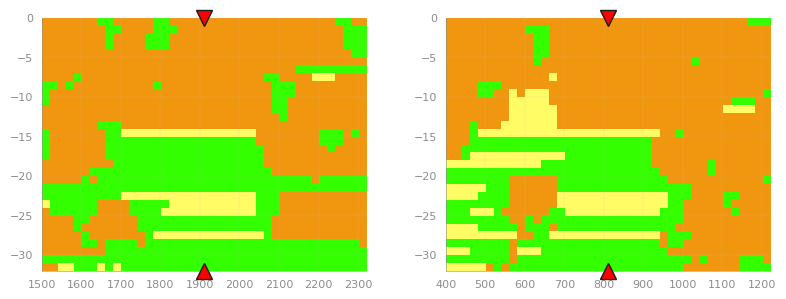


--- Generating Normalized Entropy Slices for Well: DEL-GT-01 (Run 2) ---
Saved well entropy slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5\trajectory_slices\Run 2\well_entropy_DEL-GT-01_Run_2.png


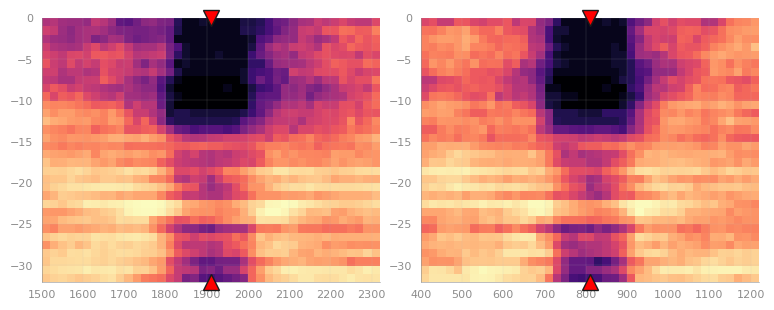

-> Generating trajectory cross-section for Well: DEL-GT-02-S2...
Saved well trajectory slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5\trajectory_slices\Run 2\well_trajectory_DEL-GT-02-S2_1samples.png


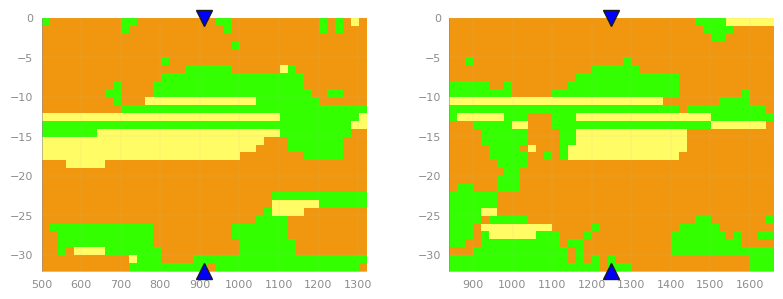


--- Generating Normalized Entropy Slices for Well: DEL-GT-02-S2 (Run 2) ---
Saved well entropy slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5\trajectory_slices\Run 2\well_entropy_DEL-GT-02-S2_Run_2.png


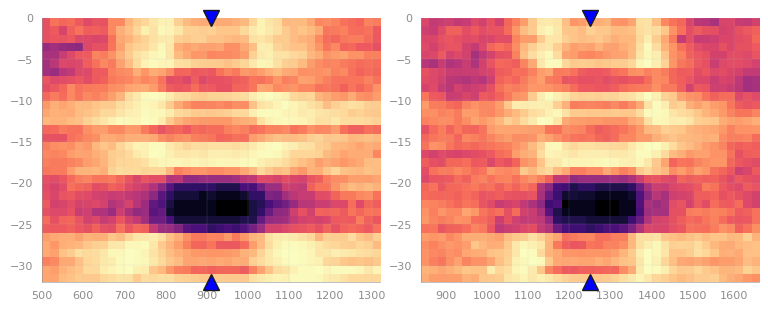


Processing Well Mismatch for Run 3...
Loaded 64 well conditioning points.

--- Well Data Mismatch ---
Evaluated 100 realizations.
Average Macro F1 Score: 0.8441
Average F1 Class 1 (Channel): 0.8952
Average F1 Class 2 (Levee): 0.7892
Average F1 Class 3 (Overbank): 0.8478
-> Generating trajectory cross-section for Well: DEL-GT-01...
Saved well trajectory slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5\trajectory_slices\Run 3\well_trajectory_DEL-GT-01_1samples.png


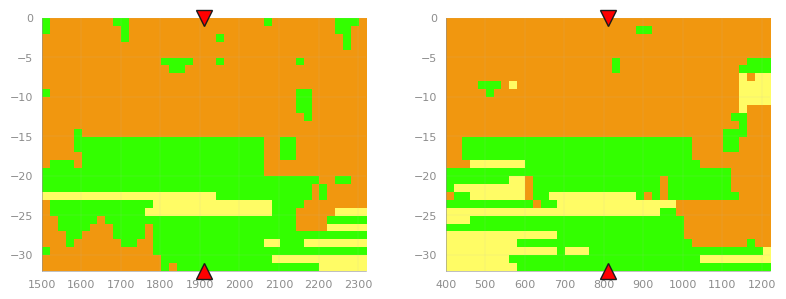


--- Generating Normalized Entropy Slices for Well: DEL-GT-01 (Run 3) ---
Saved well entropy slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5\trajectory_slices\Run 3\well_entropy_DEL-GT-01_Run_3.png


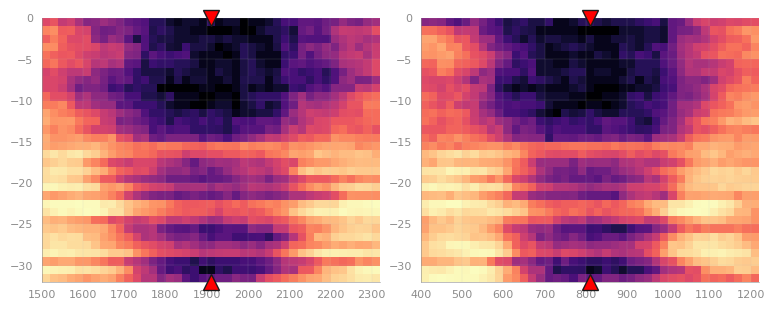

-> Generating trajectory cross-section for Well: DEL-GT-02-S2...
Saved well trajectory slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5\trajectory_slices\Run 3\well_trajectory_DEL-GT-02-S2_1samples.png


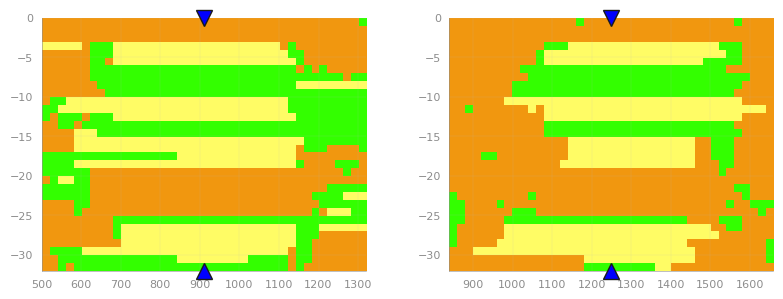


--- Generating Normalized Entropy Slices for Well: DEL-GT-02-S2 (Run 3) ---
Saved well entropy slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5\trajectory_slices\Run 3\well_entropy_DEL-GT-02-S2_Run_3.png


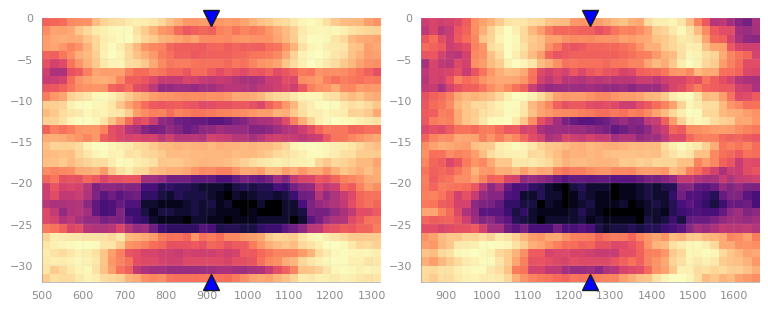


--- Generating Comparative Summary Plots ---
Saved global F1 distributions to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5\f1_score_comparisons.png
Mean accuracy score of DEL-GT-01: 0.91


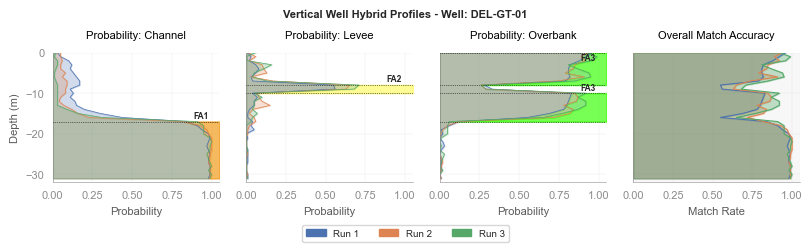

Mean accuracy score of DEL-GT-02-S2: 0.78


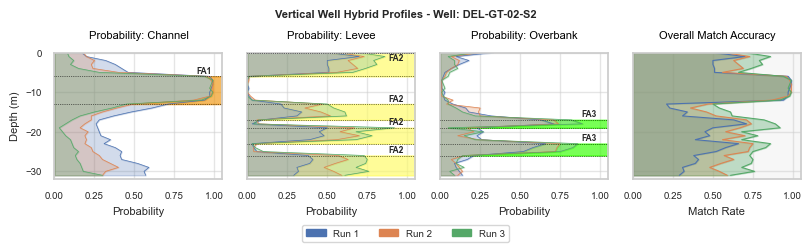

Saved depth-dependent accuracy profiles to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5\accuracy_score_across_depth.png

All mismatch evaluations and visualizations completed successfully!


In [47]:
import os

run_configs = [
    ("Run 1", gan_data_dir_01),
    ("Run 2", gan_data_dir_02),
    ("Run 3", gan_data_dir_03)
]

well_validators = []
f1_scores_results = {}

for gan_name, gan_path in run_configs:
    print(f"\n=========================================")
    print(f"Processing Well Mismatch for {gan_name}...")
    print(f"=========================================")
    
    # Initialize the validator for the current GAN run
    validator = WellMismatch(
        flumy_name='setting 2',
        gan_name=gan_name, 
        data_dir=gan_path,          
        well_data_path=well_data_path
    )
    
    # Compute the overall and per-class F1 mismatch dataframe
    df_f1_scores = validator.compute_mismatch()
    
    # Store for global comparison later
    well_validators.append(validator)
    f1_scores_results[gan_name] = df_f1_scores

    # Extract unique well names loaded from the spreadsheet tabs
    unique_wells = sorted(list(set(validator.well_names)))
    
    for actual_well in unique_wells:
        print(f"-> Generating trajectory cross-section for Well: {actual_well}...")
        
        run_output_dir = os.path.join(output_dir_03, 'trajectory_slices', gan_name)
        
        # 1. Plot Categorical Facies Slice
        validator.plot_well_trajectory_slices(
            well_name=actual_well,
            figsize=(8.27,3),
            plot_title=False, 
            plot_suptitle=False, 
            plot_axtitle=False,
            slice_range=20,
            num_samples=1,          
            show_plot=True,         
            save_plot=True,         
            output_dir=run_output_dir,
            show_legend=False
        )

        # 2. Plot Entropy Slice (Argument updated!)
        validator.plot_well_trajectory_entropy_slices(
            well_name=actual_well,
            figsize=(8.27,3.5),
            plot_title=False, 
            plot_suptitle=False, 
            plot_axtitle=False,
            slice_range=20,
            show_plot=True,         
            save_plot=True,         
            output_dir=run_output_dir,
            show_legend=False
        )

    # Global compilation block triggered at the end of the final run
    if gan_name == "Run 3":
        print(f"\n--- Generating Comparative Summary Plots ---")
        validators_dict = dict(zip([cfg[0] for cfg in run_configs], well_validators))

        # 1. Plot and save comparative histogram distributions
        f1_save_path = os.path.join(output_dir_03, 'f1_score_comparisons.png')
        # validator.plot_comparative_f1_distributions(
        #     f1_scores_results, 
        #     validators_dict, 
        #     save_path=f1_save_path
        
        # )

        print(f"Saved global F1 distributions to: {f1_save_path}")
        
        # 2. Plot and save vertical depth-dependent profile match rates
        well_accuracy_path = os.path.join(output_dir_03, 'accuracy_score_across_depth.png')
        validator.plot_hybrid_well_profile(
            validators_dict, 
            save_path=well_accuracy_path
        )
        print(f"Saved depth-dependent accuracy profiles to: {well_accuracy_path}")

print("\nAll mismatch evaluations and visualizations completed successfully!")


--- Computing Scalar Metrics comparing Run 1 to Baseline across Z-Axis ---

--- Summary Statistics (Z-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0099
Run 1 Model Entropy:  0.6855 ± 0.0751
Model-to-Baseline Spatial Entropy Ratio: 0.9903
Model-to-baseline JSD: 0.0152 ± 0.0069

--- Computing Scalar Metrics comparing Run 2 to Baseline across Z-Axis ---

--- Summary Statistics (Z-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0099
Run 2 Model Entropy:  0.6852 ± 0.0700
Model-to-Baseline Spatial Entropy Ratio: 0.9898
Model-to-baseline JSD: 0.0170 ± 0.0061

--- Computing Scalar Metrics comparing Run 3 to Baseline across Z-Axis ---

--- Summary Statistics (Z-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0099
Run 3 Model Entropy:  0.6631 ± 0.0730
Model-to-Baseline Spatial Entropy Ratio: 0.9579
Model-to-baseline JSD: 0.0282 ± 0.0083


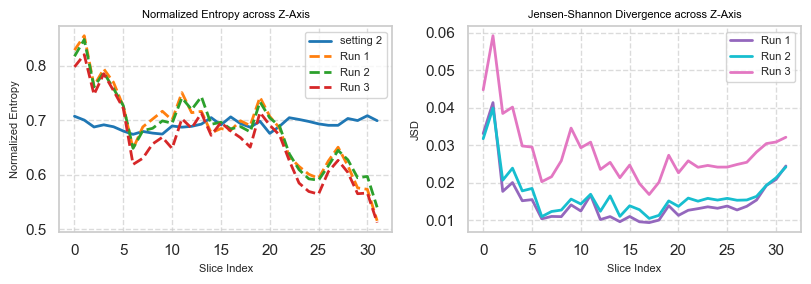


--- Computing Scalar Metrics comparing Run 1 to Baseline across X-Axis ---

--- Summary Statistics (X-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0381
Run 1 Model Entropy:  0.6855 ± 0.0360
Model-to-Baseline Spatial Entropy Ratio: 0.9903
Model-to-baseline JSD: 0.0152 ± 0.0024

--- Computing Scalar Metrics comparing Run 2 to Baseline across X-Axis ---

--- Summary Statistics (X-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0381
Run 2 Model Entropy:  0.6852 ± 0.0405
Model-to-Baseline Spatial Entropy Ratio: 0.9898
Model-to-baseline JSD: 0.0170 ± 0.0052

--- Computing Scalar Metrics comparing Run 3 to Baseline across X-Axis ---

--- Summary Statistics (X-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0381
Run 3 Model Entropy:  0.6631 ± 0.0396
Model-to-Baseline Spatial Entropy Ratio: 0.9579
Model-to-baseline JSD: 0.0282 ± 0.0149


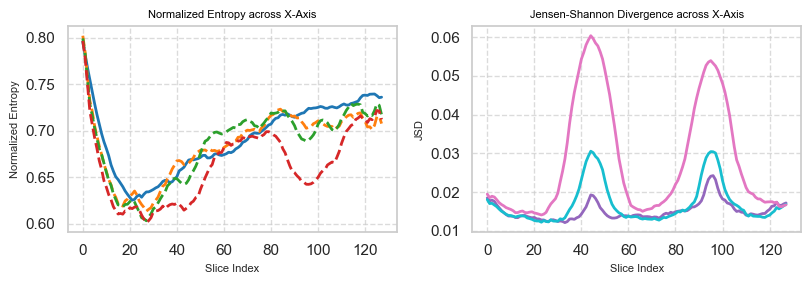


--- Computing Scalar Metrics comparing Run 1 to Baseline across Y-Axis ---

--- Summary Statistics (Y-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0461
Run 1 Model Entropy:  0.6855 ± 0.0703
Model-to-Baseline Spatial Entropy Ratio: 0.9903
Model-to-baseline JSD: 0.0152 ± 0.0036

--- Computing Scalar Metrics comparing Run 2 to Baseline across Y-Axis ---

--- Summary Statistics (Y-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0461
Run 2 Model Entropy:  0.6852 ± 0.0703
Model-to-Baseline Spatial Entropy Ratio: 0.9898
Model-to-baseline JSD: 0.0170 ± 0.0070

--- Computing Scalar Metrics comparing Run 3 to Baseline across Y-Axis ---

--- Summary Statistics (Y-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0461
Run 3 Model Entropy:  0.6631 ± 0.0608
Model-to-Baseline Spatial Entropy Ratio: 0.9579
Model-to-baseline JSD: 0.0282 ± 0.0188


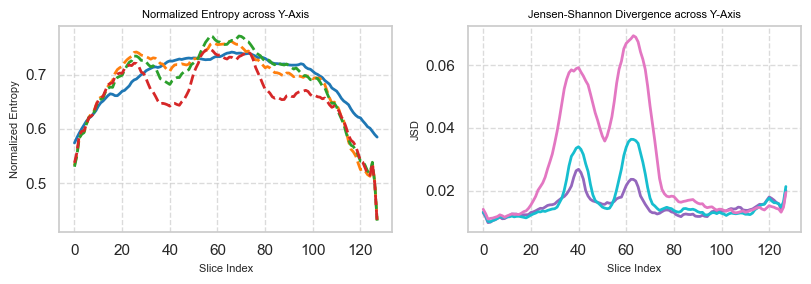

In [8]:
import matplotlib.pyplot as plt

axes_to_plot = ['Z', 'X', 'Y']

for i, axis in enumerate(axes_to_plot):
    fig, fig_axes = plt.subplots(1, 2, figsize=(8.27, 3))
    
    baseline_plotted = False
    gan_colors = ['tab:orange', 'tab:green', 'tab:red', 'tab:brown']
    jsd_colors = ['tab:purple', 'tab:cyan', 'tab:pink', 'tab:olive']
    
    for idx, validator in enumerate(validators):
        df_results, _ = validator.compute_slice_metrics(axis=axis, plot=False)
        
        slices = df_results['Slice_Index']
        flumy_entropy = df_results['Flumy_Norm_Entropy']
        gan_entropy = df_results['GAN_Norm_Entropy']
        jsd = df_results['JSD_Flumy_vs_GAN']
        
        if not baseline_plotted:
            fig_axes[0].plot(slices, flumy_entropy, label=validator.flumy_name, color='tab:blue', linewidth=2)
            baseline_plotted = True
            
        g_color = gan_colors[idx % len(gan_colors)]
        fig_axes[0].plot(slices, gan_entropy, label=f'{validator.gan_name}', color=g_color, linewidth=2, linestyle='--')
        
        j_color = jsd_colors[idx % len(jsd_colors)]
        fig_axes[1].plot(slices, jsd, label=f'{validator.gan_name}', color=j_color, linewidth=2)
        
    fig_axes[0].set_title(f'Normalized Entropy across {axis}-Axis', fontsize=8)
    fig_axes[0].set_xlabel('Slice Index', fontsize=8)
    fig_axes[0].set_ylabel('Normalized Entropy', fontsize=8)
    if i ==0:
        fig_axes[0].legend(fontsize=8)
    fig_axes[0].grid(True, linestyle='--', alpha=0.7)
    
    fig_axes[1].set_title(f'Jensen-Shannon Divergence across {axis}-Axis', fontsize=8)
    fig_axes[1].set_xlabel('Slice Index', fontsize=8)
    fig_axes[1].set_ylabel('JSD', fontsize=8)
    if i == 0:
        fig_axes[1].legend(fontsize=8)
    fig_axes[1].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(f'combined_H_and_JSD_metrics_axis_{axis}.png', dpi=300)
    plt.show()

## **Figure 4.8: Well trajectories**

X and Y slices over teh well trajectories of DEL-GT-01 and DEL-GT-02-S2. The figure is subdivided up into 3 gridspec subplots over three rows, each representing a run with a different threshold value.

Master combined plot successfully saved to:
C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5\trajectory_slices\master_grouped_facies_and_entropy.png


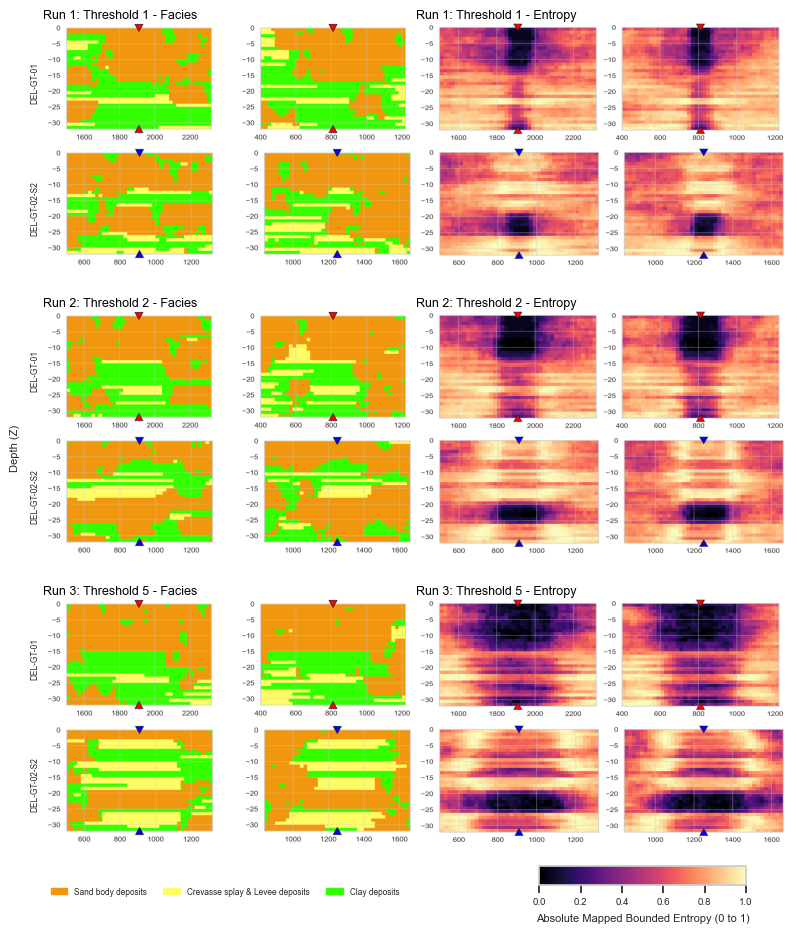

In [28]:
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# --- Base Directories and Configurations ---
base_dir = r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5\trajectory_slices"

dir_1 = os.path.join(base_dir, "Run 1")
dir_2 = os.path.join(base_dir, "Run 2")
dir_3 = os.path.join(base_dir, "Run 3")

names = [
    "Run 1: Threshold 1",
    "Run 2: Threshold 2",
    "Run 3: Threshold 5"
]

model_groups = [
    {
        "name": names[0],
        "well_1_facies": os.path.join(dir_1, "well_trajectory_DEL-GT-01_1samples.png"),
        "well_2_facies": os.path.join(dir_1, "well_trajectory_DEL-GT-02-S2_1samples.png"),
        "well_1_entropy": os.path.join(dir_1, "well_entropy_DEL-GT-01_Run_1.png"),
        "well_2_entropy": os.path.join(dir_1, "well_entropy_DEL-GT-02-S2_Run_1.png")
    },
    {
        "name": names[1],
        "well_1_facies": os.path.join(dir_2, "well_trajectory_DEL-GT-01_1samples.png"),
        "well_2_facies": os.path.join(dir_2, "well_trajectory_DEL-GT-02-S2_1samples.png"),
        "well_1_entropy": os.path.join(dir_2, "well_entropy_DEL-GT-01_Run_2.png"),
        "well_2_entropy": os.path.join(dir_2, "well_entropy_DEL-GT-02-S2_Run_2.png")
    },
    {
        "name": names[2],
        "well_1_facies": os.path.join(dir_3, "well_trajectory_DEL-GT-01_1samples.png"),
        "well_2_facies": os.path.join(dir_3, "well_trajectory_DEL-GT-02-S2_1samples.png"),
        "well_1_entropy": os.path.join(dir_3, "well_entropy_DEL-GT-01_Run_3.png"),
        "well_2_entropy": os.path.join(dir_3, "well_entropy_DEL-GT-02-S2_Run_3.png")
    }
]

legend_config = {
    'names': {
        1: 'Sand body deposits',
        4: 'Crevasse splay & Levee deposits',
        8: 'Clay deposits'
    },
    'colors': {
        1: '#f1970f',
        4: '#fffc65',
        8: '#33ff00'
    }
}

# --- Plotting Function ---
def plot_combined_gridspec(groups, facies_legend, plot_size=(8.27, 9.5)):
    fig = plt.figure(figsize=plot_size)
    
    # Reduced outer hspace from 0.3 to 0.15
    outer_gs = gridspec.GridSpec(3, 1, figure=fig, hspace=0.15)

    for i, group in enumerate(groups):
        inner_gs = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer_gs[i], hspace=0.008, wspace=0.005)
        
        # NEW: Added row_label parameter to handle well names dynamically
        def add_image(ax, img_path, title=None, row_label=None):
            if os.path.exists(img_path):
                img = mpimg.imread(img_path)
                # Added aspect='auto' to force the image to fill the grid cell completely
                ax.imshow(img, aspect='auto')
            else:
                ax.text(0.5, 0.5, f"Missing:\n{os.path.basename(img_path)}", 
                        ha='center', va='center', color='red', fontsize=6)
            
            ax.axis('off')
            
            if title:
                ax.set_title(title, loc='left', fontsize=9, pad=1)
                
            # NEW: Attach the well name label vertically to the left edge of the plot
            if row_label:
                ax.text(-0.01, 0.5, row_label, transform=ax.transAxes, 
                        rotation=90, va='center', ha='right', fontsize=6)

        # --- Column 0: Facies ---
        # Pass the row_labels ONLY to the first column (Facies) so they act as row headers
        ax_facies_w1 = fig.add_subplot(inner_gs[0, 0])
        add_image(ax_facies_w1, group["well_1_facies"], title=f"{group['name']} - Facies", row_label="DEL-GT-01")
        
        ax_facies_w2 = fig.add_subplot(inner_gs[1, 0])
        add_image(ax_facies_w2, group["well_2_facies"], row_label="DEL-GT-02-S2")

        # --- Column 1: Entropy ---
        ax_entropy_w1 = fig.add_subplot(inner_gs[0, 1])
        add_image(ax_entropy_w1, group["well_1_entropy"], title=f"{group['name']} - Entropy")
        
        ax_entropy_w2 = fig.add_subplot(inner_gs[1, 1])
        add_image(ax_entropy_w2, group["well_2_entropy"])


    # NEW: Added a shared global Y-axis title for Depth
    fig.supylabel("Depth (Z)", fontsize=8, x=0.01)

    # UPDATED: Increased left margin (from 0.05 to 0.1) to accommodate the new row labels and Z-axis title
    fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.08)

    # --- Add Global Legends ---
    legend_patches = [mpatches.Patch(color=facies_legend['colors'][key], label=facies_legend['names'][key]) 
                      for key in facies_legend['names']]
    
    fig.legend(
        handles=legend_patches, 
        loc='lower left', 
        ncol=3, 
        frameon=True, 
        facecolor='white', 
        edgecolor='none',
        fontsize=6,
        bbox_to_anchor=(0.05, 0.02) # Snug to the updated left margin
    )

    cbar_ax = fig.add_axes([0.65, 0.04, 0.25, 0.02]) 
    norm = mcolors.Normalize(vmin=0, vmax=1.0)
    sm = plt.cm.ScalarMappable(cmap='magma', norm=norm)
    sm.set_array([]) 

    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Absolute Mapped Bounded Entropy (0 to 1)', fontsize=8, labelpad=5)
    cbar.ax.tick_params(labelsize=7)

    output_path = os.path.join(base_dir, "master_grouped_facies_and_entropy.png")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Master combined plot successfully saved to:\n{output_path}")

    plt.show()

plot_combined_gridspec(model_groups, legend_config)

Master combined plot successfully saved to:
C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5\trajectory_slices\master_grouped_facies_and_entropy.png


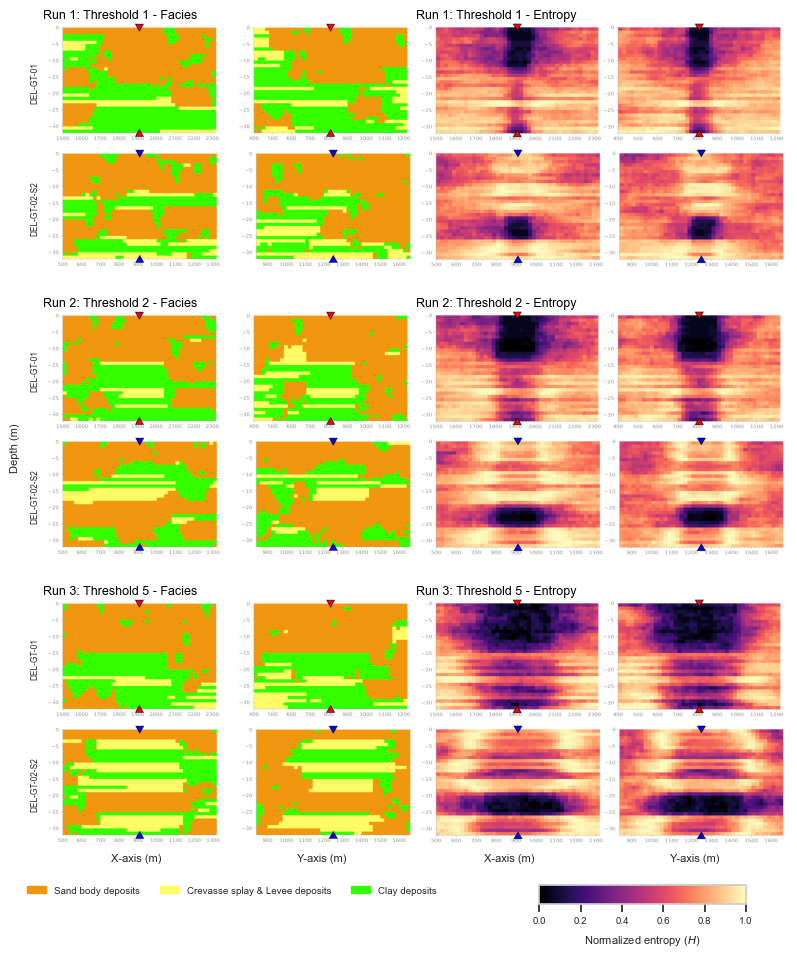

In [21]:
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

base_dir = r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\Run_1_3_model_5_adjusted_loss_3000_steps_threshold_5\trajectory_slices"

dir_1 = os.path.join(base_dir, "Run 1")
dir_2 = os.path.join(base_dir, "Run 2")
dir_3 = os.path.join(base_dir, "Run 3")

names = [
    "Run 1: Threshold 1",
    "Run 2: Threshold 2",
    "Run 3: Threshold 5"
]

model_groups = [
    {
        "name": names[0],
        "well_1_facies": os.path.join(dir_1, "well_trajectory_DEL-GT-01_1samples.png"),
        "well_2_facies": os.path.join(dir_1, "well_trajectory_DEL-GT-02-S2_1samples.png"),
        "well_1_entropy": os.path.join(dir_1, "well_entropy_DEL-GT-01_Run_1.png"),
        "well_2_entropy": os.path.join(dir_1, "well_entropy_DEL-GT-02-S2_Run_1.png")
    },
    {
        "name": names[1],
        "well_1_facies": os.path.join(dir_2, "well_trajectory_DEL-GT-01_1samples.png"),
        "well_2_facies": os.path.join(dir_2, "well_trajectory_DEL-GT-02-S2_1samples.png"),
        "well_1_entropy": os.path.join(dir_2, "well_entropy_DEL-GT-01_Run_2.png"),
        "well_2_entropy": os.path.join(dir_2, "well_entropy_DEL-GT-02-S2_Run_2.png")
    },
    {
        "name": names[2],
        "well_1_facies": os.path.join(dir_3, "well_trajectory_DEL-GT-01_1samples.png"),
        "well_2_facies": os.path.join(dir_3, "well_trajectory_DEL-GT-02-S2_1samples.png"),
        "well_1_entropy": os.path.join(dir_3, "well_entropy_DEL-GT-01_Run_3.png"),
        "well_2_entropy": os.path.join(dir_3, "well_entropy_DEL-GT-02-S2_Run_3.png")
    }
]

legend_config = {
    'names': {
        1: 'Sand body deposits',
        4: 'Crevasse splay & Levee deposits',
        8: 'Clay deposits'
    },
    'colors': {
        1: '#f1970f',
        4: '#fffc65',
        8: '#33ff00'
    }
}

def plot_combined_gridspec(groups, facies_legend, plot_size=(8.27, 9.5)):
    fig = plt.figure(figsize=plot_size)
    
    # Reduced outer hspace from 0.3 to 0.15
    outer_gs = gridspec.GridSpec(3, 1, figure=fig, hspace=0.15)

    for i, group in enumerate(groups):
        inner_gs = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer_gs[i], hspace=0.008, wspace=0.005)
        
        # UPDATED: Replaced bottom_label with bottom_labels (a list of tuples)
        def add_image(ax, img_path, title=None, row_label=None, bottom_labels=None):
            if os.path.exists(img_path):
                img = mpimg.imread(img_path)
                # Added aspect='auto' to force the image to fill the grid cell completely
                ax.imshow(img, aspect='auto')
            else:
                ax.text(0.5, 0.5, f"Missing:\n{os.path.basename(img_path)}", 
                        ha='center', va='center', color='red', fontsize=6)
            
            ax.axis('off')
            
            if title:
                ax.set_title(title, loc='left', fontsize=9, pad=1)
                
            if row_label:
                ax.text(-0.01, 0.5, row_label, transform=ax.transAxes, 
                        rotation=90, va='center', ha='right', fontsize=6)
            
            if bottom_labels:
                for text, x_pos in bottom_labels:
                    ax.text(x_pos, -0.05, text, transform=ax.transAxes, 
                            va='top', ha='center', fontsize=8)

        # Check if this is the last group to add the bottom column labels
        is_last_group = (i == len(groups) - 1)
        
        # 0.25 aligns with the left plot in the image, 0.75 aligns with the right plot
        axis_labels = [("X-axis (m)", 0.25), ("Y-axis (m)", 0.75)] if is_last_group else None

        # Pass the row_labels ONLY to the first column (Facies) so they act as row headers
        ax_facies_w1 = fig.add_subplot(inner_gs[0, 0])
        add_image(ax_facies_w1, group["well_1_facies"], title=f"{group['name']} - Facies", row_label="DEL-GT-01")
        
        ax_facies_w2 = fig.add_subplot(inner_gs[1, 0])
        add_image(ax_facies_w2, group["well_2_facies"], row_label="DEL-GT-02-S2", bottom_labels=axis_labels)

        ax_entropy_w1 = fig.add_subplot(inner_gs[0, 1])
        add_image(ax_entropy_w1, group["well_1_entropy"], title=f"{group['name']} - Entropy")
        
        ax_entropy_w2 = fig.add_subplot(inner_gs[1, 1])
        add_image(ax_entropy_w2, group["well_2_entropy"], bottom_labels=axis_labels)


    # Shared global Y-axis title for Depth
    fig.supylabel("Depth (m)", fontsize=8, x=0.01)

    # Increased bottom margin to accommodate the new column bottom labels
    fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.08)

    # --- Add Global Legends ---
    legend_patches = [mpatches.Patch(color=facies_legend['colors'][key], label=facies_legend['names'][key]) 
                      for key in facies_legend['names']]
    
    fig.legend(
        handles=legend_patches, 
        loc='lower left', 
        ncol=3, 
        frameon=True, 
        facecolor='white', 
        edgecolor='none',
        fontsize=7,
        bbox_to_anchor=(0.02, 0.02)
    )

    cbar_ax = fig.add_axes([0.65, 0.02, 0.25, 0.02]) 
    norm = mcolors.Normalize(vmin=0, vmax=1.0)
    sm = plt.cm.ScalarMappable(cmap='magma', norm=norm)
    sm.set_array([]) 

    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(f'Normalized entropy ($H$)', fontsize=8, labelpad=5)
    cbar.ax.tick_params(labelsize=7)

    output_path = os.path.join(base_dir, "master_grouped_facies_and_entropy.png")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Master combined plot successfully saved to:\n{output_path}")

    plt.show()

plot_combined_gridspec(model_groups, legend_config)

## **Figure: Threshold explanantion**

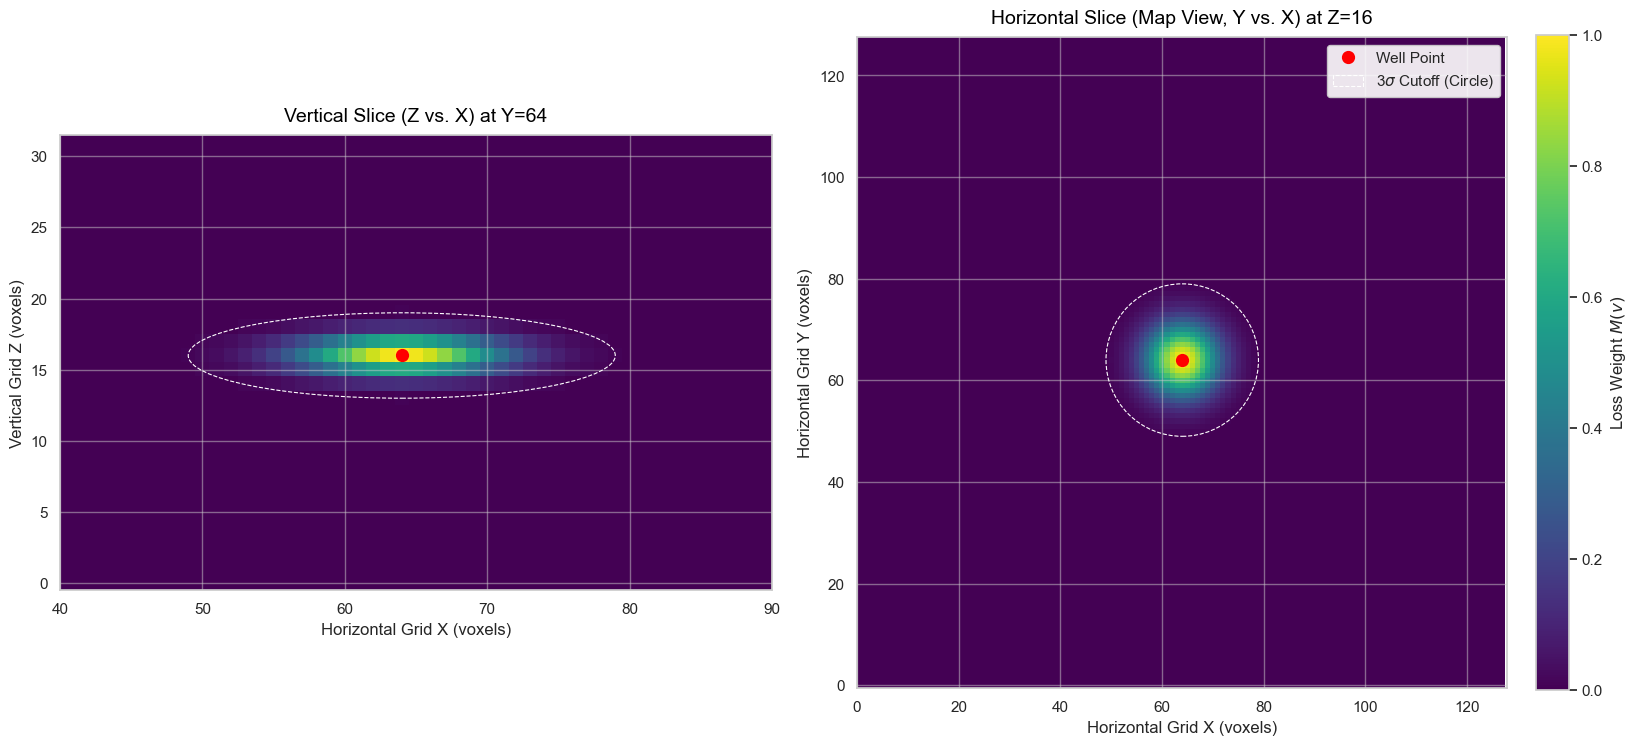

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt
from matplotlib.patches import Ellipse

# 1. Setup the full 3D grid (Z, Y, X) matching your generator output
shape = (32, 128, 128)
sigma = 5.0
cutoff = 3 * sigma

# 2. Place a single well point in the center of the 3D grid
dist_input = np.ones(shape, dtype=int)
well_z, well_y, well_x = 16, 64, 64
dist_input[well_z, well_y, well_x] = 0

# 3. Calculate 3D Anisotropic Euclidean distance
# Spacing forces Z-distance to accumulate 10x faster than Y or X
spacing = (5.0, 1.0, 1.0)
distance = distance_transform_edt(dist_input, sampling=spacing)

# 4. Apply the Gaussian Decay Mask to the entire 3D volume
mask = np.exp(-(distance**2) / (2 * sigma**2))

# 5. Apply the soft cutoff
mask[distance > cutoff] = 0.0

# 6. Extract the 2D slices for plotting
# Vertical cross-section (Z vs X) slicing exactly through the well's Y coordinate
slice_zx = mask[:, well_y, :]
slice_yx = mask[well_z, :, :]

# 7. Plotting the publication-ready figure
# --> Added sharex=True to link the horizontal axes of both subplots
fig, axes = plt.subplots(1, 2, figsize=(8.27*2, 4*2), sharex=False)

# --- Subplot 1: Vertical Slice (Z vs X) ---
ax1 = axes[0]
c1 = ax1.imshow(slice_zx, cmap='viridis', interpolation='nearest', origin='lower')
ax1.plot(well_x, well_z, 'o',color='red', markersize=8, markeredgewidth=1.5, label="Well Point")

# --> Changed linewidth to 0.8 for a thinner boundary line
ellipse1 = Ellipse((well_x, well_z), 
                   width=2*(cutoff/spacing[2]),   # X-axis width
                   height=2*(cutoff/spacing[0]),  # Z-axis height
                   color='white', fill=False, linestyle='--', linewidth=0.8, 
                   label=f"3$\sigma$ Cutoff (Ellipse)")
ax1.add_patch(ellipse1)
ax1.set_title(f"Vertical Slice (Z vs. X) at Y={well_y}", fontsize=14, pad=10)
ax1.set_xlabel("Horizontal Grid X (voxels)", fontsize=12)
ax1.set_ylabel("Vertical Grid Z (voxels)", fontsize=12)
ax1.set_xlim(40, 90)

# --- Subplot 2: Horizontal Slice (Y vs X) ---
ax2 = axes[1]
c2 = ax2.imshow(slice_yx, cmap='viridis', interpolation='nearest', origin='lower')
ax2.plot(well_x, well_y, 'o', color='red', markersize=8, markeredgewidth=1.5, label="Well Point")

# --> Changed linewidth to 0.8 for a thinner boundary line
circle2 = plt.Circle((well_x, well_y), cutoff/spacing[1], color='white', fill=False, linestyle='--', linewidth=0.8, label=f"3$\sigma$ Cutoff (Circle)")
ax2.add_patch(circle2)
ax2.set_title(f"Horizontal Slice (Map View, Y vs. X) at Z={well_z}", fontsize=14, pad=10)
ax2.set_xlabel("Horizontal Grid X (voxels)", fontsize=12)
ax2.set_ylabel("Horizontal Grid Y (voxels)", fontsize=12)
ax2.legend(loc="upper right", framealpha=0.9)
ax2.set_xlim(0, 128)
ax2.set_aspect('equal')
fig.colorbar(c2, ax=ax2, fraction=0.046, pad=0.04, label='Loss Weight $M(v)$')

plt.tight_layout()

# --> Increased output resolution to 400 DPI
plt.savefig(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_optimization_plots\3D_anisotropic_gaussian_mask.png", dpi=400)
plt.show()